In [1]:
# Python 3.13.1

In [2]:
# 데이터 처리
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, WeightedRandomSampler
from collections import Counter
import numpy as np

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim

# 시각화
import matplotlib.pyplot as plt

In [3]:
# 경로 설정
TRAIN_DIR = r"/Users/ihaeni/dev/ai/computervision/data/train"
TEST_DIR = r"/Users/ihaeni/dev/ai/computervision/data/test"
BATCH_SIZE = 8

# Train용 전처리 (Augmentation 포함)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Validation/Test용 전처리 (단순 Resize)
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# 전체 train dataset 불러오기
full_train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transform)

# train:val = 8:2 split
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# test dataset
test_dataset = datasets.ImageFolder(root=TEST_DIR, transform=test_transform)

# 클래스 별 갯수 확인
print(Counter(full_train_dataset.targets))

# Sampler 설정
train_indices = train_dataset.indices
train_targets = [full_train_dataset.targets[i] for i in train_indices]

class_counts = Counter(train_targets)
class_sample_count = np.array([class_counts[i] for i in range(len(class_counts))])
weights = 1. / class_sample_count
samples_weight = [weights[label] for label in train_targets]
sampler = WeightedRandomSampler(samples_weight, num_samples=len(samples_weight), replacement=True)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 클래스 이름 확인
print("Classes:", full_train_dataset.classes)

Counter({1: 137, 3: 76, 5: 74, 0: 70, 2: 70, 4: 70, 6: 70, 7: 70, 8: 70, 9: 70})
Classes: ['1', '10', '2', '3', '4', '5', '6', '7', '8', '9']


In [4]:
# 클래스 수 확인
num_classes = len(full_train_dataset.classes)

# densenet121 불러오기 (pretrained)
from torchvision.models import densenet121, DenseNet121_Weights
model = densenet121(weights=DenseNet121_Weights.DEFAULT)

# classifier를 두 개의 Linear Layer와 ReLU 활성화 함수로 구성된 새로운 구조로 교체
model.classifier = nn.Sequential(
    nn.Linear(model.classifier.in_features, 256), # 중간 차원 줄이기
    nn.ReLU(),  # 비선형성 부여
    nn.Linear(256, num_classes) # 최종 출력 클래스 수 맞추기
)

# 장치 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [5]:
# 배치 하나 꺼내기
images, labels = next(iter(train_loader))
images, labels = images.to(device), labels.to(device)

# 예측하기
with torch.no_grad():
    outputs = model(images)
    probs = torch.softmax(outputs, dim=1)
    preds = torch.argmax(probs, dim=1)

# 결과 출력
print("예측 인덱스:", preds)
print("정답 인덱스:", labels)

예측 인덱스: tensor([8, 8, 8, 8, 8, 8, 8, 8])
정답 인덱스: tensor([2, 6, 5, 9, 2, 1, 0, 6])


In [6]:
# 손실 함수 및 옵티마이저
criterion = nn.CrossEntropyLoss()

#optimizer = optim.Adam(model.parameters(), lr=0.001)
optimizer = optim.AdamW(model.parameters(), lr=0.0005)

scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

# 학습 기록용 리스트
train_accs, val_accs = [], []
train_losses, val_losses = [], []
best_val_acc = 0.0
best_train_acc = 0.0
best_model_state = None

# 학습 루프
for epoch in range(10):
    model.train()

    train_correct, train_total, train_loss_sum = 0, 0, 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad() # optimizer 초기화

        # 예측
        outputs = model(images) 

        # 손실계산
        loss = criterion(outputs, labels) 
        train_loss_sum += loss.item()

        loss.backward() # 역전파 gradient 계산
        optimizer.step() # 계산된 gradient로 모델 파라미터를 업데이트

        # 정확도계산
        _, predicted = torch.max(outputs, 1)
        train_correct += (predicted == labels).sum().item()
        train_total += labels.size(0)

    # learning rate 스케줄 업데이트
    scheduler.step() 

    # 정확도 및 손실 계산, 저장
    train_acc = 100 * train_correct / train_total
    train_loss = train_loss_sum / len(train_loader)
    train_accs.append(train_acc)
    train_losses.append(train_loss)

    # 검증 모드 전환
    model.eval()
    
    # 초기화
    val_correct, val_total, val_loss_sum = 0, 0, 0.0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
    
            # 예측
            outputs = model(images)
    
            # 손실 계산
            loss = criterion(outputs, labels)
            val_loss_sum += loss.item()

            # 검증은 gradient 계산 안 함
            
            # 정확도 계산
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)
    
    # 정확도 및 손실 계산, 저장
    val_acc = 100 * val_correct / val_total
    val_loss = val_loss_sum / len(val_loader)
    val_accs.append(val_acc)
    val_losses.append(val_loss)
     
    print(f"[Epoch {epoch+1}] Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%")

    # Best 모델 저장
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_train_acc = train_acc 
        best_model_state = model.state_dict().copy()
        # print("✅ Best model updated!")

# 학습 완료 후 Best 모델 로드
model.load_state_dict(best_model_state)
print(f"Best Validation Accuracy: {best_val_acc:.2f}%")

[Epoch 1] Train Acc: 36.23%, Val Acc: 42.95%
[Epoch 2] Train Acc: 61.03%, Val Acc: 60.90%
[Epoch 3] Train Acc: 66.18%, Val Acc: 78.85%
[Epoch 4] Train Acc: 75.52%, Val Acc: 83.33%
[Epoch 5] Train Acc: 81.80%, Val Acc: 80.13%
[Epoch 6] Train Acc: 89.37%, Val Acc: 91.67%
[Epoch 7] Train Acc: 93.08%, Val Acc: 92.31%
[Epoch 8] Train Acc: 95.49%, Val Acc: 94.87%
[Epoch 9] Train Acc: 95.49%, Val Acc: 96.15%
[Epoch 10] Train Acc: 95.97%, Val Acc: 95.51%
Best Validation Accuracy: 96.15%


예측 인덱스: tensor([0, 0, 3, 8, 3, 4, 0, 3])
정답 인덱스: tensor([0, 0, 3, 8, 3, 4, 0, 3])


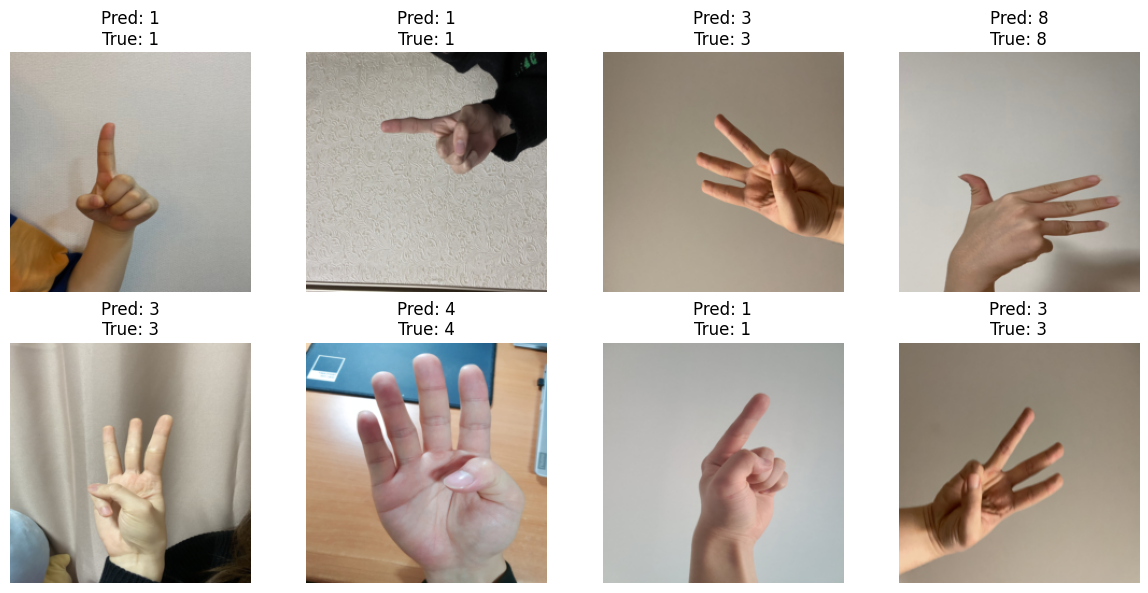

In [11]:
# 배치 하나 꺼내기(학습 후)
images, labels = next(iter(train_loader))
images, labels = images.to(device), labels.to(device)

# 예측하기
with torch.no_grad():
    outputs = model(images)
    probs = torch.softmax(outputs, dim=1)
    preds = torch.argmax(probs, dim=1)

# 결과 출력
print("예측 인덱스:", preds)
print("정답 인덱스:", labels)

# 클래스 이름 가져오기
class_names = full_train_dataset.classes

# 시각화
plt.figure(figsize=(12, 6))
for i in range(min(8, len(images))):  # 최대 8개만 시각화
    img = images[i].cpu().permute(1, 2, 0)
    img = img * 0.5 + 0.5  # Normalize 복원
    img = img.clamp(0, 1)

    plt.subplot(2, 4, i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Pred: {class_names[preds[i]]}\nTrue: {class_names[labels[i]]}")

plt.tight_layout()
plt.show()

In [8]:
# Test 데이터셋으로 최종 성능 평가
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

# Train / Val / Test Accuracy를 단순 Print
test_acc = 100 * correct / total
print(f"Final Accuracy - Train: {best_train_acc:.2f}%, Val: {best_val_acc:.2f}%, Test: {test_acc:.2f}%")

Final Accuracy - Train: 95.49%, Val: 96.15%, Test: 92.12%


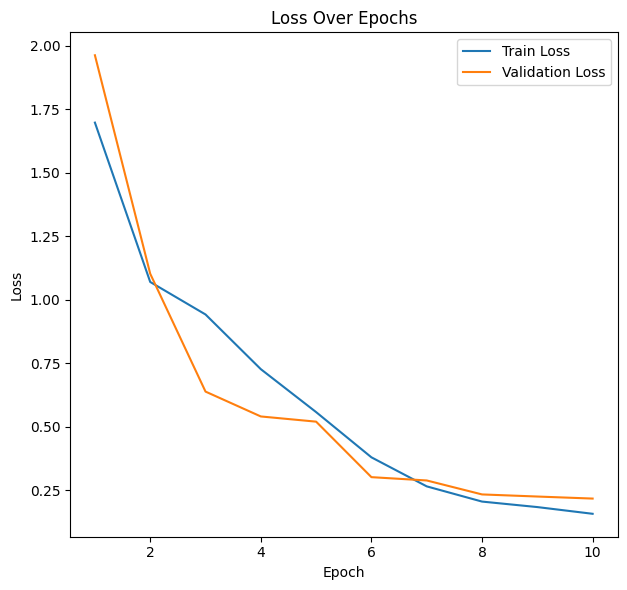

In [9]:
# 학습 과정 시각화
epochs = range(1, len(train_accs) + 1)

plt.figure(figsize=(12, 6))

# Loss 그래프
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")
plt.title("Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()